# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Question 1:**

1. Adding a penalty makes large coefficients expensive, so the model prefers simpler solutions unless bigger coefficients truly improve fit. The takeaway is: it controls complexity and helps prevent overfitting.

2. Regularization lets us tune model complexity with the penalty size. More penalty gives higher bias but lower variance; less penalty gives lower bias but higher variance. The takeaway is: it gives a direct way to choose the best bias-variance balance.

3. LASSO uses an absolute value penalty and can set some coefficients exactly to zero, so it does variable selection. Ridge uses a squared penalty and usually only shrinks coefficients toward zero, not all the way to zero. The takeaway is: LASSO is more interpretable, Ridge usually keeps all predictors.

4. We usually standardize numeric variables to z-scores. Otherwise, variables on larger scales get penalized unfairly. The takeaway is that scaling makes the penalty comparable across predictors.

5. The penalty is usually chosen with cross-validation. We test many values of the penalty and pick the one with the lowest validation error. The takeaway is to choose the penalty based on out-of-sample performance.

6. No, we usually do not include the penalty term in the cross-validated MSE. We use the penalty only to fit the model on the training folds, then evaluate plain prediction error on the validation folds. The takeaway is: CV should measure how well the model predicts new data.



**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [12]:
! git clone https://github.com/anishjagota/undergrad_ml_assignments

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

In [4]:
#2.1
cars = pd.read_csv('/content/undergrad_ml_assignments/data/cars_hw.csv')
cars.head()
cars = cars.drop(columns=['Unnamed: 0'], errors='ignore')
cars['Age'] = 2024 - cars['Make_Year']
features = ['Mileage_Run', 'Age']
X = cars[features]
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out(features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
X_scaled = pd.DataFrame(X_scaled, columns=poly_names)
X_scaled.head()


,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,0.124692,-0.013092,-0.137673,-0.075274,-0.193924,-0.294615,-0.247857,-0.243677,-0.319030
1,-0.872334,0.341858,-0.791316,-0.632282,0.150120,-0.661216,-0.697319,-0.524369,-0.022524
2,-0.493517,-0.722993,-0.600623,-0.687077,-0.744394,-0.581863,-0.652312,-0.702020,-0.701506
3,-0.241655,-0.013092,-0.434732,-0.307676,-0.193924,-0.492295,-0.460043,-0.382252,-0.319030
4,-0.674578,-0.013092,-0.700583,-0.582312,-0.193924,-0.627064,-0.649938,-0.546011,-0.319030


In [5]:
#2.2
y = cars['Price']

ols = LinearRegression()
ols.fit(X_scaled, y)

coef_table = pd.Series(ols.coef_, index=poly_names)
coef_table
coef_table['Mileage_Run Age']


np.float64(-1251592.3408260453)

In [6]:
#2.3

alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000, random_state=100)
lasso_cv.fit(X_scaled, y)
lasso_cv.alpha_

np.float64(483.2930238571752)

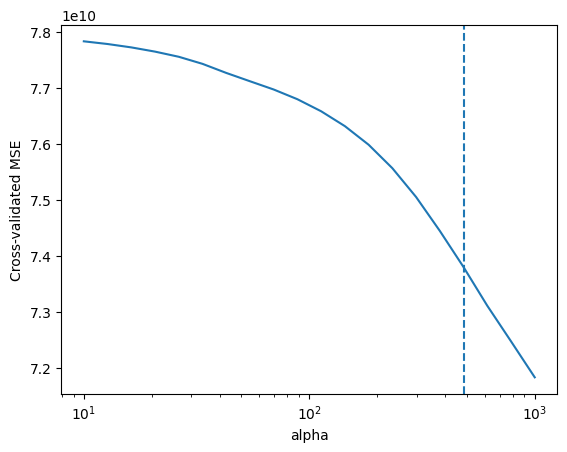

483.2930238571752


In [7]:
#2.4
median_mse = np.median(lasso_cv.mse_path_, axis=1)
alpha_star = lasso_cv.alpha_
plt.figure()
plt.plot(lasso_cv.alphas_, median_mse)
plt.axvline(x=alpha_star, linestyle='--')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.show()

print(alpha_star)

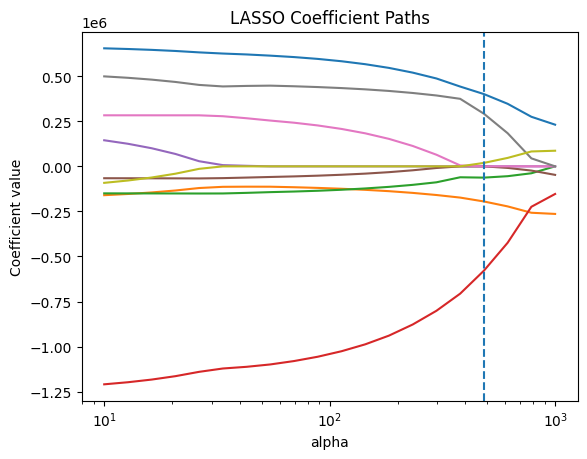

In [8]:
#2.5
coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=50000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=poly_names[i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.axvline(x=alpha_star, linestyle='--')
plt.show()

In [9]:
#2.6
lasso_coef = pd.Series(lasso_cv.coef_, index=poly_names)
selected_features = lasso_coef[lasso_coef != 0]
zero_features = lasso_coef[lasso_coef == 0]
print("Selected features:")
print(selected_features)
print("\nNumber set to zero:", len(zero_features))
print("Total number of features:", len(lasso_coef))
print("Proportion set to zero:", len(zero_features) / len(lasso_coef))

Selected features:
Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Mileage_Run Age^2    292015.025679
Age^3                 19133.908573
dtype: float64

Number set to zero: 3
Total number of features: 9
Proportion set to zero: 0.3333333333333333


In [10]:
#2.7
compare = pd.DataFrame({
    'OLS': coef_table,
    'LASSO': lasso_coef
})
compare['OLS_abs'] = compare['OLS'].abs()
compare['LASSO_abs'] = compare['LASSO'].abs()
compare['Increased_in_magnitude'] = compare['LASSO_abs'] > compare['OLS_abs']
compare['Changed_sign'] = np.sign(compare['OLS']) != np.sign(compare['LASSO'])
compare[['OLS', 'LASSO', 'Increased_in_magnitude', 'Changed_sign']]

,OLS,LASSO,Increased_in_magnitude,Changed_sign
Mileage_Run,6.686165e+05,401025.259657,False,False
Age,-1.841941e+05,-194803.116695,True,False
Mileage_Run^2,-1.494679e+05,-62539.290093,False,False
Mileage_Run Age,-1.251592e+06,-578788.661090,False,False
Age^2,2.156399e+05,-0.000000,False,True
Mileage_Run^3,-6.514490e+04,-0.000000,False,True
Mileage_Run^2 Age,2.833392e+05,0.000000,False,True
Mileage_Run Age^2,5.280829e+05,292015.025679,False,False
Age^3,-1.389370e+05,19133.908573,False,True


The LASSO coefficients are mostly smaller in magnitude than the OLS coefficients, so the main effect is shrinkage toward zero. The only coefficient that increases in magnitude is Age. Several terms are set exactly to zero, and the terms Age², Mileage_Run³, Mileage_Run² Age, and Age³ change sign because LASSO shrinks them to zero or near zero.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [11]:
hf = pd.read_csv('/content/undergrad_ml_assignments/data/heart_failure_clinical_records_dataset.csv')
hf.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/undergrad_ml_assignments/data/heart_failure_clinical_records_dataset.csv'

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

**Question 4:**

1. The objective function for ridge regression is the usual mean squared error plus a penalty on the slope coefficient 𝑏1. In words, we choose 𝑏0 and 𝑏1 to fit the data well, but we also penalize large values of b1 by adding 𝛼(𝑏1)^2 to the loss. The key takeaway is that ridge regression balances fit and simplicity by discouraging a large slope.

2. after taking the respective derivatives:

b0=0

b1=[average of (x times y)] / [average of (x squared) + alpha]

This happens because both x and y are mean-centered, so the intercept drops out. Compared with OLS, the numerator stays the same, but ridge adds alpha to the denominator. The key takeaway is that ridge keeps the same basic slope formula as OLS, but the extra alpha in the denominator shrinks the slope toward zero.


3. As α increases, the slope coefficient b1 gets smaller in magnitude and is pushed toward 0. The key takeaway is that a larger ridge penalty means more shrinkage of the slope.

4. With the LASSO penalty α∣b1​∣, the main challenge is that the absolute value is not differentiable at 0, so we cannot solve it as smoothly as ridge by just taking ordinary derivatives everywhere. It is optimal to set b1=0 when the benefit from fitting the data is too small to justify the penalty. In this one-variable case, that happens when the correlation between x and y is small enough that the penalty dominates. The key takeaway is that LASSO can set the slope exactly equal to zero, which is why it performs variable selection.


